最初に以下のセルを実行

In [1]:
%%capture
!pip install japanize-matplotlib
import japanize_matplotlib
from IPython.display import Markdown, display

In [2]:
NOTEBOOK_TITLE = "_01 異常検知"

import os
from pathlib import Path

OUTPUT_DIR = Path('figures') / NOTEBOOK_TITLE
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR = Path('cache')
CACHE_DIR.mkdir(exist_ok=True, parents=True)

# キャッシュディレクトリを指定
os.environ['TORCH_HOME'] = str(CACHE_DIR)

display(Markdown(f"# {NOTEBOOK_TITLE}"))

# _01 異常検知

In [ ]:
%%capture
!pip install Cython
## `pip install eif` fails due to the following issue: https://github.com/sahandha/eif/pull/37
## Thus, installing a fixed PR
!pip install git+https://github.com/NAThompson/eif.git@fix_build

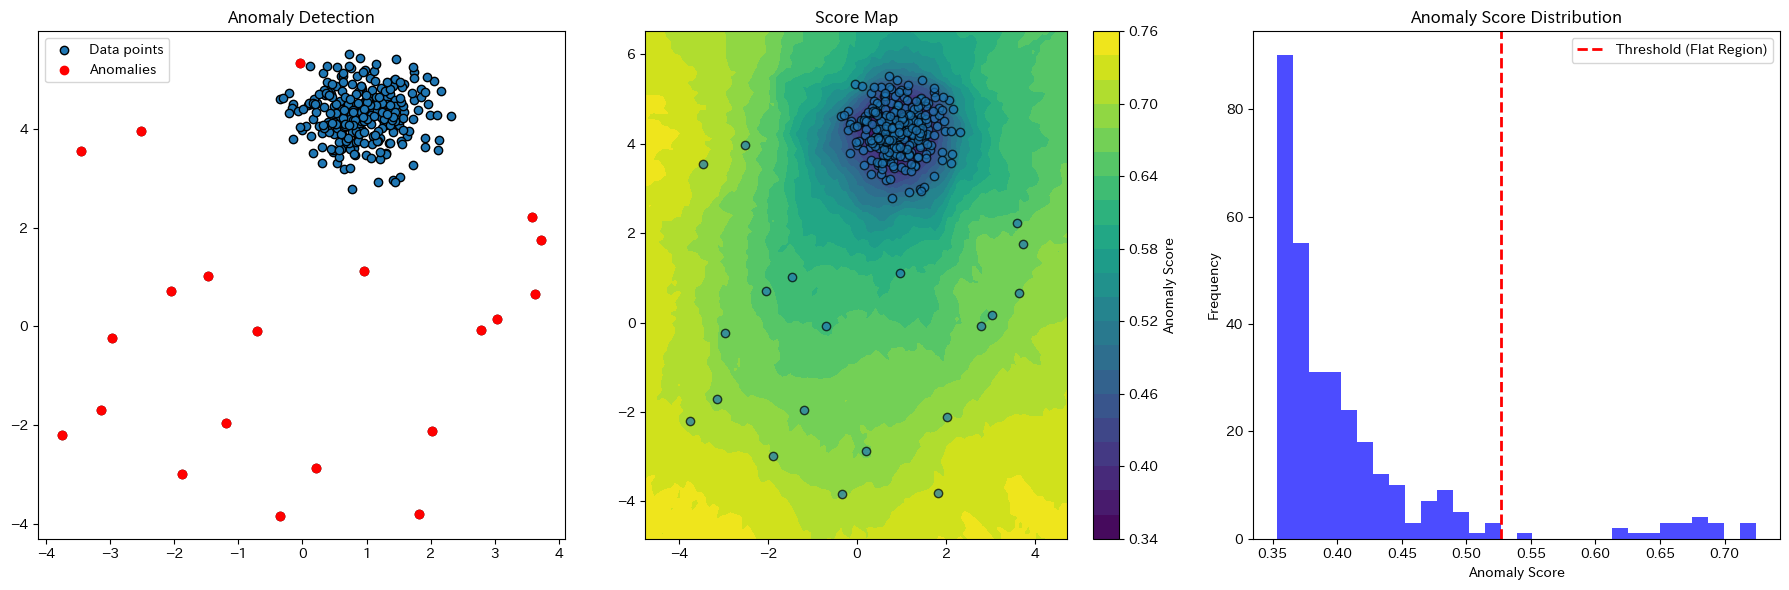

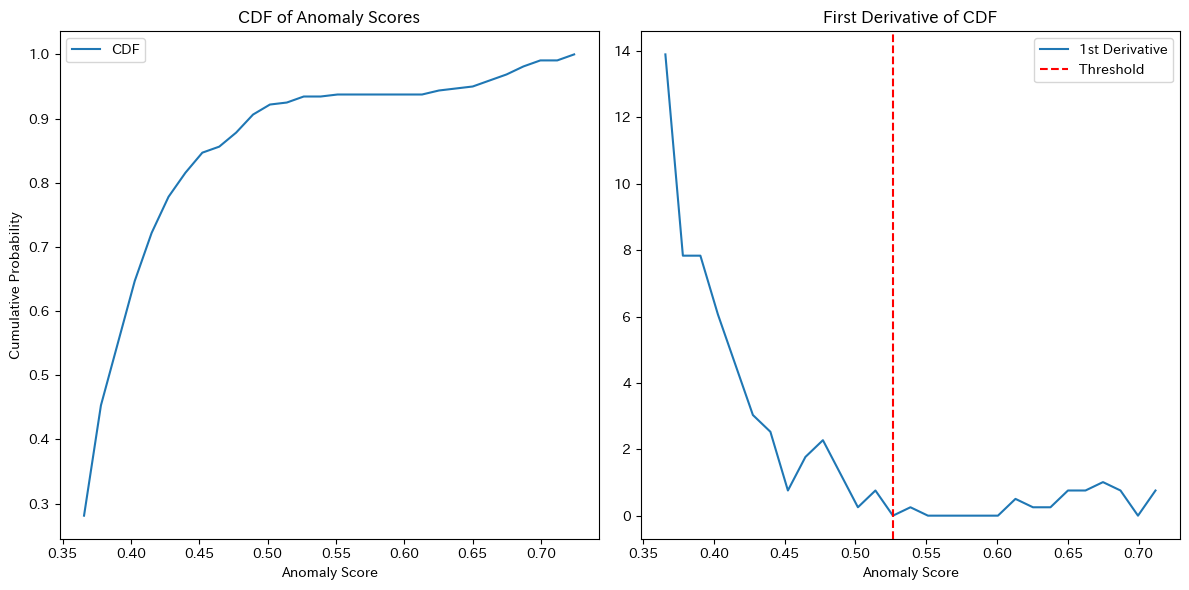


### Explanation:
- **Left Plot**: Original anomaly detection result with anomalies highlighted in red.
- **Middle Plot**: Anomaly score map showing the spatial distribution of anomaly likelihood.
- **Right Plot**: Histogram of anomaly scores, with the threshold dynamically calculated at the flat region.
- **Calculated Threshold (Flat Region Method)**: 0.5265


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from eif import iForest
from sklearn.datasets import make_blobs
from IPython.display import display, Markdown

class ElbowMethodFlatRegion:
    def __init__(self, scores, bins=30, flat_threshold=0.01):
        """
        Initialize with anomaly scores.
        
        Parameters:
        - scores: Array of anomaly scores.
        - bins: Number of bins for histogram/CDF calculation.
        - flat_threshold: Derivative threshold for identifying flat regions.
        """
        self.scores = scores
        self.bins = bins
        self.flat_threshold = flat_threshold
        self.threshold = None
        self.cdf = None
        self.first_derivative = None

    def calculate_threshold(self):
        """Calculate threshold by detecting the first flat region in the CDF."""
        hist, bin_edges = np.histogram(self.scores, bins=self.bins, density=True)
        self.cdf = np.cumsum(hist * np.diff(bin_edges))
        self.first_derivative = np.diff(self.cdf) / np.diff(bin_edges[:-1])

        # Detect first flat region (first point where derivative drops below flat_threshold)
        flat_region_indices = np.where(self.first_derivative < self.flat_threshold)[0]
        if len(flat_region_indices) > 0:
            threshold_index = flat_region_indices[0]
            self.threshold = bin_edges[threshold_index + 1]
        else:
            self.threshold = np.percentile(self.scores, 95)
        return self.threshold

    def plot_cdf_and_derivative(self):
        """Plot the CDF and its first derivative."""
        bin_edges = np.linspace(min(self.scores), max(self.scores), self.bins + 1)
        
        plt.figure(figsize=(12, 6))
        
        # Plot CDF
        plt.subplot(1, 2, 1)
        plt.plot(bin_edges[1:], self.cdf, label='CDF')
        plt.title("CDF of Anomaly Scores")
        plt.xlabel("Anomaly Score")
        plt.ylabel("Cumulative Probability")
        plt.legend()
        
        # Plot first derivative
        plt.subplot(1, 2, 2)
        plt.plot(bin_edges[1:-1], self.first_derivative, label='1st Derivative')
        if self.threshold:
            plt.axvline(x=self.threshold, color='red', linestyle='dashed', label='Threshold')
        plt.title("First Derivative of CDF")
        plt.xlabel("Anomaly Score")
        plt.legend()
        
        plt.tight_layout()
        plt.show()

# Data generation
np.random.seed(0)
X, _ = make_blobs(n_samples=300, centers=1, cluster_std=0.5)
outliers = np.random.uniform(low=-4, high=4, size=(20, 2))
X = np.vstack((X, outliers))

# EIF Model
forest = iForest(X, ntrees=100, sample_size=256, ExtensionLevel=1)

# Calculate anomaly scores
scores = forest.compute_paths(X_in=X)

# Apply the updated Elbow Method for flat region detection
elbow_flat = ElbowMethodFlatRegion(scores)
threshold = elbow_flat.calculate_threshold()
anomalies = X[scores > threshold]

# Original Anomaly Detection Plot
plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1)
plt.scatter(X[:, 0], X[:, 1], label="Data points", edgecolor='k')
plt.scatter(anomalies[:, 0], anomalies[:, 1], color='red', label="Anomalies")
plt.title("Anomaly Detection")
plt.legend()

# Score Map
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
grid_points = np.c_[xx.ravel(), yy.ravel()]
grid_scores = forest.compute_paths(X_in=grid_points).reshape(xx.shape)

# Plot score map
plt.subplot(1, 3, 2)
plt.contourf(xx, yy, grid_scores, levels=20, cmap='viridis')
plt.colorbar(label='Anomaly Score')
plt.scatter(X[:, 0], X[:, 1], edgecolor='k', label='Data points', alpha=0.7)
plt.title("Score Map")

# Histogram of Anomaly Scores
plt.subplot(1, 3, 3)
plt.hist(scores, bins=30, color='blue', alpha=0.7)
plt.axvline(x=threshold, color='red', linestyle='dashed', linewidth=2, label="Threshold (Flat Region)")
plt.title("Anomaly Score Distribution")
plt.xlabel("Anomaly Score")
plt.ylabel("Frequency")
plt.legend()

plt.tight_layout()
plt.show()

elbow_flat.plot_cdf_and_derivative()

display(Markdown(f'''
### Explanation:
- **Left Plot**: Original anomaly detection result with anomalies highlighted in red.
- **Middle Plot**: Anomaly score map showing the spatial distribution of anomaly likelihood.
- **Right Plot**: Histogram of anomaly scores, with the threshold dynamically calculated at the flat region.
- **Calculated Threshold (Flat Region Method)**: {threshold:.4f}
'''))